In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
xls = pd.ExcelFile("AutoBMD.xlsx")
file_path = "AutoBMD.xlsx"
print(xls.sheet_names)

['Aggregate Gradation', 'Volumetrics', 'IDEAL-CT', 'HWTT']


In [33]:
file_path = "AutoBMD.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Aggregate Gradation",
    header=3
)

In [34]:
combined, valid = aggregate_gradation(df)

print("Gradation Valid:", valid)

ValueError: Could not find specification rows.

In [28]:
# CLEAN COLUMN NAMES
# -------------------------
df.columns = df.columns.astype(str).str.strip()

# -------------------------
# SIEVE COLUMNS
# -------------------------
value_cols = df.columns[4:]

# convert sieve names into numbers
sieves = pd.to_numeric(value_cols, errors='coerce')

# keep only numeric sieve columns
valid_mask = ~sieves.isna()

value_cols = value_cols[valid_mask]
sieves = sieves[valid_mask].astype(float).values

# -------------------------
# FIND COMBINED ROW
# -------------------------
combined_row = df[
    df["Aggregate Type"].astype(str).str.contains("Combined", case=False, na=False)
]

combined = pd.to_numeric(
    combined_row.iloc[0][value_cols],
    errors='coerce'
).values

# -------------------------
# FIND SPEC ROWS
# -------------------------
print(df["Aggregate Type"].unique())

['3/4" Qtz Chips' '3/8" Down Qtz' 'Qtz Man Sand' 'Akron Sand' 'RAP '
 'Combined Gradation' nan]


In [39]:
# =========================
# MODULE A - GRADATION
# =========================
def aggregate_gradation(df):

    # -------------------------
    # CLEAN COLUMN NAMES
    # -------------------------
    df.columns = df.columns.astype(str).str.strip()

    # -------------------------
    # SIEVE COLUMNS
    # -------------------------
    sieve_cols = df.columns[4:]

    sieve_sizes = pd.to_numeric(sieve_cols, errors='coerce')

    valid_mask = ~sieve_sizes.isna()

    sieve_cols = sieve_cols[valid_mask]
    sieves = sieve_sizes[valid_mask].astype(float).values

    # -------------------------
    # COMBINED ROW
    # -------------------------
    combined_row = df[
        df["Aggregate Type"].astype(str).str.contains("Combined", case=False, na=False)
    ]

    combined = pd.to_numeric(
        combined_row.iloc[0][sieve_cols],
        errors='coerce'
    ).values

    # -------------------------
    # PRINT AVAILABLE ROW NAMES
    # -------------------------
    print(df["Aggregate Type"].unique())

    # -------------------------
    # SPEC ROWS
    # CHANGE THESE WORDS IF NEEDED
    # -------------------------
    min_row = df[
        df["Aggregate Type"].astype(str).str.contains("Min", case=False, na=False)
    ]

    max_row = df[
        df["Aggregate Type"].astype(str).str.contains("Max", case=False, na=False)
    ]

    min_control = pd.to_numeric(
        min_row.iloc[0][sieve_cols],
        errors='coerce'
    ).values

    max_control = pd.to_numeric(
        max_row.iloc[0][sieve_cols],
        errors='coerce'
    ).values

  
    # -------------------------
    # VALIDATION
    # -------------------------
    valid = np.all(
        (combined >= min_control) &
        (combined <= max_control)
    )

    return combined, valid

NameError: name 'min_control' is not defined

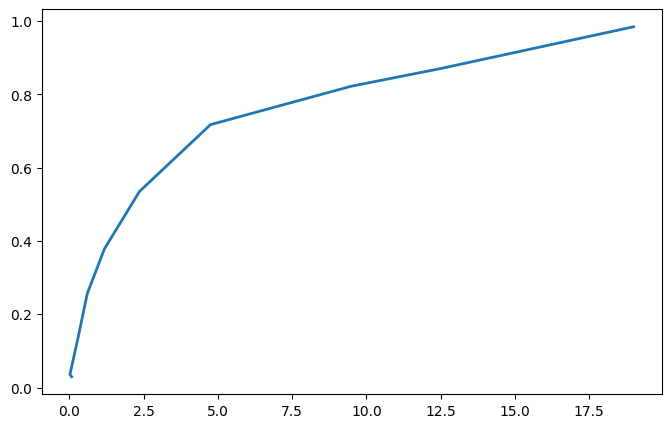

In [41]:
  # -------------------------
    # PLOT
    # -------------------------
plt.figure(figsize=(8,5))

plt.plot(sieves, combined, linewidth=2, label="Combined Gradation")
plt.plot(sieves, min_control, "--", label="Min Spec")
plt.plot(sieves, max_control, "--", label="Max Spec")

plt.xlabel("Sieve Size (mm)")
plt.ylabel("% Passing")
plt.title("Aggregate Gradation")

plt.grid(True)
plt.legend()

plt.gca().invert_xaxis()

plt.show()


In [48]:
# =========================
# MODULE B - VOLUMETRICS (FIXED)
# =========================

def volumetric_properties(df):

    # -------------------------
    # CLEAN COLUMN NAMES
    # -------------------------
    df.columns = df.columns.astype(str).str.strip()

    # FIX DOUBLE SPACE ISSUE IN YOUR FILE
    df = df.rename(columns={
        "Final  Gmb": "Gmb",   # <-- your file has TWO spaces
        "Final Gmm": "Gmm"
    })

    # -------------------------
    # CONVERT TO NUMERIC
    # -------------------------
    df["Gmb"] = pd.to_numeric(df["Gmb"], errors="coerce")
    df["Gmm"] = pd.to_numeric(df["Gmm"], errors="coerce")
    df["Va"]  = pd.to_numeric(df["Va"], errors="coerce")

    # -------------------------
    # AIR VOIDS (already given, just standardize)
    # -------------------------
    df["Air_Voids"] = df["Va"]

    # -------------------------
    # VMA (cannot be fully derived because Gsb is NOT in your sheet)
    # so we compute only if possible, otherwise NaN-safe fallback
    # -------------------------
    df["VMA"] = np.nan  # placeholder since Gsb is missing

    # -------------------------
    # STATUS CHECK
    # -------------------------
    df["Status"] = df["Air_Voids"].apply(
        lambda x: "VALID" if 6.5 <= x <= 7.5 else "INVALID"
    )

    # -------------------------
    # OUTPUT
    # -------------------------
    return df[[
        "Gmm",
        "Gmb",
        "Air_Voids",
        "VMA",
        "Status"
    ]]

In [49]:
vol_df = pd.read_excel(
    file_path,
    sheet_name="Volumetrics",
    header=2
)

results = volumetric_properties(vol_df)

print(results)

   Gmm  Gmb  Air_Voids  VMA   Status
0  NaN  NaN        NaN  NaN  INVALID
1  NaN  NaN        NaN  NaN  INVALID
2  NaN  NaN        NaN  NaN  INVALID


In [63]:
# =========================
# MODULE C - IDEAL-CT
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------
# CT INDEX CORE CALCULATION
# -------------------------------------------------
def compute_ct_index(disp, load, thickness, diameter=150.0):

    disp = np.asarray(disp, dtype=float)
    load = np.asarray(load, dtype=float)

    valid = ~np.isnan(disp) & ~np.isnan(load)
    disp, load = disp[valid], load[valid]

    if disp.size < 3:
        raise ValueError("Insufficient data points for CT analysis.")

    peak_pos = np.argmax(load)
    peak_load = load[peak_pos]
    peak_disp = disp[peak_pos]

    # Energy under curve (work input)
    energy = np.trapezoid(load * 1000, disp / 1000)

    fracture_energy = energy / ((diameter / 1000) * (thickness / 1000))

    # post-peak region
    disp_post = disp[peak_pos:]
    load_post = load[peak_pos:]

    if len(load_post) < 2:
        raise ValueError("Insufficient post-peak response.")

    target = 0.75 * peak_load

    cross_idx = np.where(load_post <= target)[0]
    if cross_idx.size == 0:
        raise ValueError("No 75% load drop detected.")

    k = cross_idx[0]

    # interpolate 75% displacement
    if k == 0:
        disp_75 = disp_post[0]
    else:
        x0, y0 = disp_post[k - 1], load_post[k - 1]
        x1, y1 = disp_post[k], load_post[k]

        disp_75 = x1 if y1 == y0 else x0 + (target - y0) * (x1 - x0) / (y1 - y0)

    # slope near 75%
    if k == 0:
        x0, y0 = disp_post[0], load_post[0]
        x1, y1 = disp_post[1], load_post[1]
    else:
        x0, y0 = disp_post[k - 1], load_post[k - 1]
        x1, y1 = disp_post[k], load_post[k]

    slope = abs((y1 - y0) / (x1 - x0)) if x1 != x0 else np.inf

    if slope == 0:
        raise ValueError("Zero slope at 75% point.")

    ct_value = (thickness / 62.0) * (fracture_energy / slope) * (disp_75 / diameter)

    return {
        "Peak Load (kN)": peak_load,
        "Peak Disp (mm)": peak_disp,
        "P75 (kN)": target,
        "l75 (mm)": disp_75,
        "|m75| (kN/mm)": slope,
        "Fracture Energy (J/m²)": fracture_energy,
        "CTindex": ct_value
    }


# -------------------------------------------------
# RUN ALL SAMPLES + PLOT
# -------------------------------------------------
def run_ideal_ct(samples, sample_meta):

    results = []

    plt.figure(figsize=(10, 6))

    cmap = plt.cm.tab10

    for i, (name, data) in enumerate(samples.items()):

        disp = data["Displacement_mm"].values
        load = data["Load_kN"].values

        t = sample_meta[name]["Thickness (mm)"]
        D = sample_meta[name]["Diameter (mm)"]

        try:
            res = compute_ct_index(disp, load, t, D)
            res["Sample"] = name
            res["Thickness (mm)"] = t
            results.append(res)

            color = cmap(i % 10)

            plt.plot(disp, load, color=color, label=name)
            plt.scatter(res["Peak Disp (mm)"], res["Peak Load (kN)"], color=color)
            plt.scatter(res["l75 (mm)"], res["P75 (kN)"], color=color)

        except Exception as e:
            results.append({
                "Sample": name,
                "Thickness (mm)": t,
                "CTindex": f"Error: {e}"
            })

    plt.xlabel("Displacement (mm)")
    plt.ylabel("Load (kN)")
    plt.title("IDEAL-CT Load–Displacement Curves")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    ct_df = pd.DataFrame(results)

    print("\n========== CT INDEX SUMMARY ==========")
    print(ct_df)

    ct_df.to_excel("IDEALCT_Results.xlsx", index=False)

    return ct_df

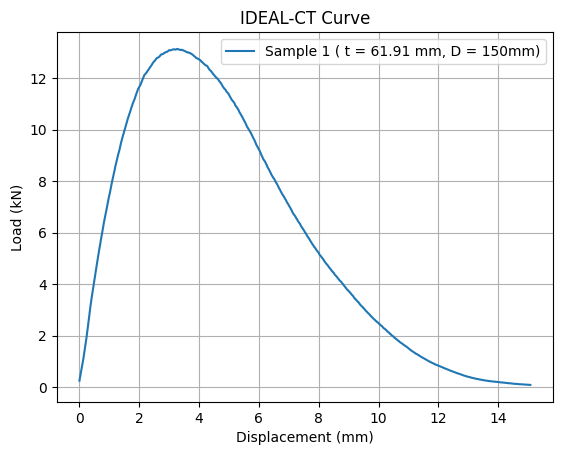

CT Index: 23.14766660228111
Samples found: 3


In [66]:
raw_ct = pd.read_excel(file_path, sheet_name="IDEAL-CT")

raw_ct.columns = raw_ct.columns.astype(str).str.strip()

ct_index, samples = ideal_ct(raw_ct)

print("CT Index:", ct_index)
print("Samples found:", len(samples))

In [68]:
import matplotlib.pyplot as plt

def plot_all_ct_samples(samples):

    plt.figure(figsize=(10, 6))

    for name, df in samples.items():

        disp = df["Displacement_mm"].values
        load = df["Load_kN"].values

        plt.plot(disp, load, linewidth=2, label=name)

    plt.xlabel("Displacement (mm)")
    plt.ylabel("Load (kN)")
    plt.title("IDEAL-CT: Load vs Displacement (All Samples)")
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()

    plt.show()

In [61]:

# =========================
# MODULE D - HWTT
# =========================

def hwtt(df):

    # Automatically grab first pair
    cycle_col = [c for c in df.columns if "LC" in c][0]
    rut_col   = [c for c in df.columns if "RD" in c][0]

    cycles = df[cycle_col].dropna().values
    rut = df[rut_col].dropna().values

    slope = np.gradient(rut, cycles)
    sip_idx = np.argmax(np.gradient(slope))

    failure = np.where(rut >= 12.5)[0]
    failure_cycle = cycles[failure[0]] if len(failure) > 0 else None

    status = "PASS" if cycles[-1] >= 20000 else "FAIL"

    plt.figure()
    plt.plot(cycles, rut, label="Rut Depth")
    plt.axvline(cycles[sip_idx], linestyle="--", label="SIP")

    if failure_cycle is not None:
        plt.axvline(failure_cycle, color="red", label="Failure")

    plt.title("HWTT")
    plt.xlabel("Cycles")
    plt.ylabel("Rut Depth")
    plt.legend()
    plt.grid()
    plt.show()

    return status, failure_cycle


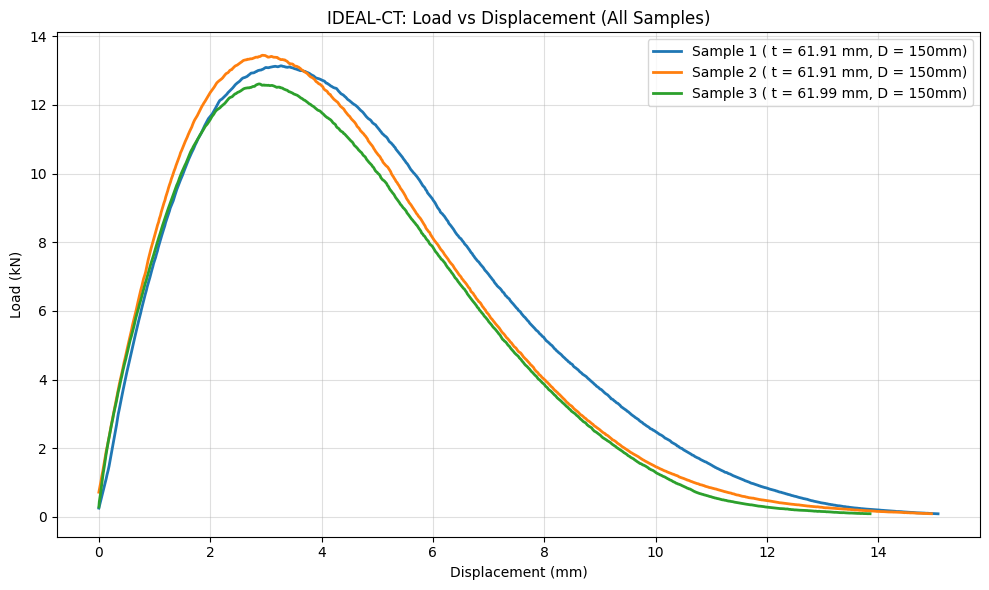

In [69]:
plot_all_ct_samples(samples)

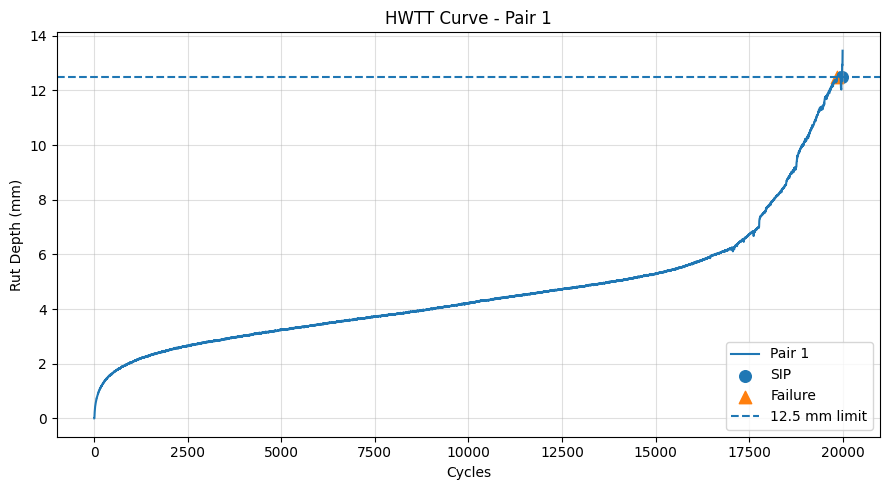

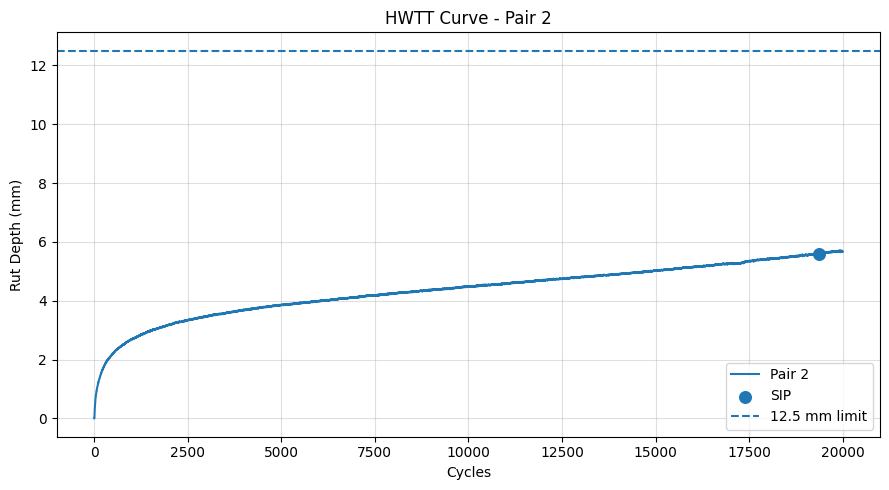


========== HWTT SUMMARY ==========
   Sample  SIP Cycles  SIP Rut Depth  Failure Cycles  Failure Rut Depth Status
0  Pair 1     19972.0          12.49         19860.0               12.5   FAIL
1  Pair 2     19368.0           5.59             NaN                NaN   PASS


In [71]:
# =============================================================
# MODULE D - HWTT RUTTING ANALYZER (CLEAN VERSION)
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re


# -------------------------
# LOAD AND CLEAN DATA
# -------------------------
hwtt_raw = pd.read_excel(file_path, sheet_name="HWTT")
hwtt_raw.columns = hwtt_raw.columns.astype(str).str.strip()


# -------------------------
# EXTRACT SAMPLE PAIRS
# -------------------------
hwtt_samples = {}

pairs = [(1, 2), (4, 5)]  # your sheet structure

for i, (c1, c2) in enumerate(pairs, start=1):

    df_pair = hwtt_raw.iloc[:, [c1, c2]].copy()
    df_pair.columns = ["Cycles", "Rut_Depth_mm"]

    df_pair = df_pair.apply(pd.to_numeric, errors='coerce').dropna()
    df_pair = df_pair[df_pair["Cycles"] >= 0].reset_index(drop=True)

    hwtt_samples[f"Pair {i}"] = df_pair


# -------------------------
# SIP DETECTION
# -------------------------
def detect_sip(cycles, rut, min_cycle=2000, window=25):

    cycles = np.asarray(cycles, dtype=float)
    rut = np.asarray(rut, dtype=float)

    valid = ~np.isnan(cycles) & ~np.isnan(rut)
    cycles, rut = cycles[valid], rut[valid]

    if len(cycles) < 10:
        raise ValueError("Not enough data for SIP detection.")

    smooth = pd.Series(rut).rolling(window, center=True, min_periods=1).mean().to_numpy()

    slope = np.gradient(smooth, cycles)
    curvature = np.gradient(slope, cycles)

    mask = cycles >= min_cycle
    if not np.any(mask):
        raise ValueError("No valid SIP search region.")

    idx = np.where(mask)[0][np.argmax(curvature[mask])]

    return cycles[idx], rut[idx]


# -------------------------
# FAILURE POINT
# -------------------------
def detect_failure(cycles, rut, limit=12.5):

    cycles = np.asarray(cycles, dtype=float)
    rut = np.asarray(rut, dtype=float)

    valid = ~np.isnan(cycles) & ~np.isnan(rut)
    cycles, rut = cycles[valid], rut[valid]

    over = np.where(rut >= limit)[0]

    if len(over) == 0:
        return None, None

    i = over[0]

    if i == 0:
        return cycles[0], limit

    x0, y0 = cycles[i - 1], rut[i - 1]
    x1, y1 = cycles[i], rut[i]

    if y1 == y0:
        return x1, limit

    xf = x0 + (limit - y0) * (x1 - x0) / (y1 - y0)

    return xf, limit


# -------------------------
# PASS / FAIL RULE
# -------------------------
def check_performance(fail_cycles, target=20000):

    if fail_cycles is None or np.isnan(fail_cycles):
        return "PASS"

    return "PASS" if fail_cycles >= target else "FAIL"


# -------------------------
# RUN ANALYSIS + PLOT
# -------------------------
results = []

for name, df in hwtt_samples.items():

    cycles = df["Cycles"].values
    rut = df["Rut_Depth_mm"].values

    try:
        sip_x, sip_y = detect_sip(cycles, rut)
        fail_x, fail_y = detect_failure(cycles, rut)

        status = check_performance(fail_x)

        results.append({
            "Sample": name,
            "SIP Cycles": sip_x,
            "SIP Rut Depth": sip_y,
            "Failure Cycles": fail_x,
            "Failure Rut Depth": fail_y,
            "Status": status
        })

        plt.figure(figsize=(9, 5))
        plt.plot(cycles, rut, label=name)

        plt.scatter(sip_x, sip_y, marker="o", s=70, label="SIP")

        if fail_x is not None:
            plt.scatter(fail_x, fail_y, marker="^", s=80, label="Failure")

        plt.axhline(12.5, linestyle="--", label="12.5 mm limit")

        plt.xlabel("Cycles")
        plt.ylabel("Rut Depth (mm)")
        plt.title(f"HWTT Curve - {name}")
        plt.grid(alpha=0.4)
        plt.legend()
        plt.tight_layout()
        plt.show()

    except Exception as e:
        results.append({
            "Sample": name,
            "Status": f"Error: {e}"
        })


# -------------------------
# SUMMARY TABLE
# -------------------------
hwtt_df = pd.DataFrame(results)

print("\n========== HWTT SUMMARY ==========")
print(hwtt_df)